Class Distribution:
RB: 356
NRB: 699

Sigmoid Activation Function
Iteration 0: Cost = 0.6931
Iteration 100: Cost = 0.5116
Iteration 200: Cost = 0.4621
Iteration 300: Cost = 0.4339
Iteration 400: Cost = 0.4143
Iteration 500: Cost = 0.3996
Iteration 600: Cost = 0.3879
Iteration 700: Cost = 0.3783
Iteration 800: Cost = 0.3703
Iteration 900: Cost = 0.3635

Test Accuracy: 82.94 %


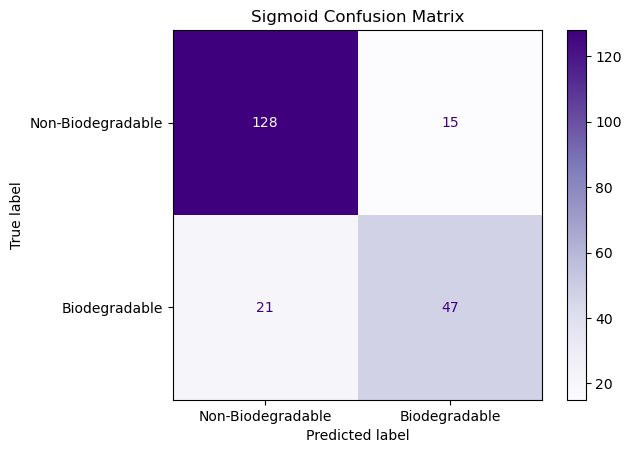


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       143
           1       0.76      0.69      0.72        68

    accuracy                           0.83       211
   macro avg       0.81      0.79      0.80       211
weighted avg       0.83      0.83      0.83       211


Tanh Activation Function
Iteration 0: Cost = 7.8572
Iteration 100: Cost = 0.5381
Iteration 200: Cost = 0.4835
Iteration 300: Cost = 0.4711
Iteration 400: Cost = 0.4417
Iteration 500: Cost = 0.4572
Iteration 600: Cost = 0.4518
Iteration 700: Cost = 0.4475
Iteration 800: Cost = 0.4440
Iteration 900: Cost = 0.4191

Test Accuracy: 84.83 %


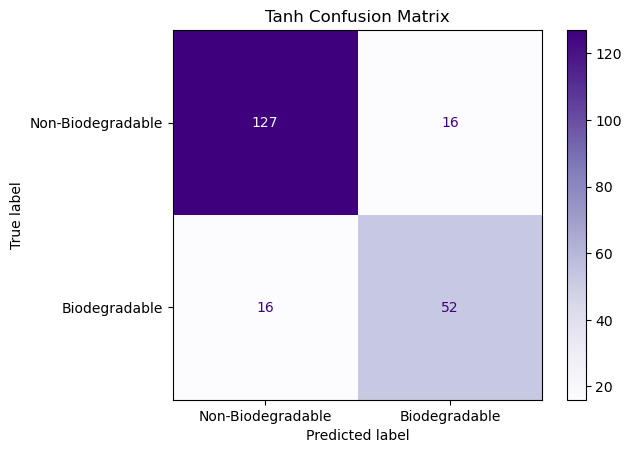


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       143
           1       0.76      0.76      0.76        68

    accuracy                           0.85       211
   macro avg       0.83      0.83      0.83       211
weighted avg       0.85      0.85      0.85       211


ReLU Activation Function
Iteration 0: Cost = 7.8572
Iteration 100: Cost = 0.5020
Iteration 200: Cost = 0.4915
Iteration 300: Cost = 0.4356
Iteration 400: Cost = 0.4256
Iteration 500: Cost = 0.4196
Iteration 600: Cost = 0.4155
Iteration 700: Cost = 0.4123
Iteration 800: Cost = 0.4100
Iteration 900: Cost = 0.4089

Test Accuracy: 84.83 %


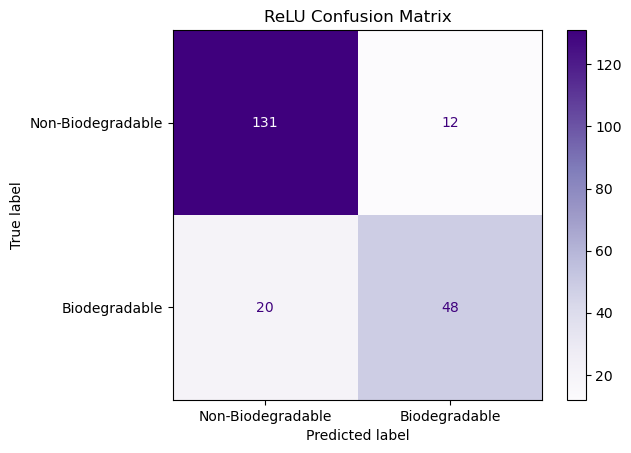


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       143
           1       0.80      0.71      0.75        68

    accuracy                           0.85       211
   macro avg       0.83      0.81      0.82       211
weighted avg       0.85      0.85      0.85       211


FINAL COMPARISON
Sigmoid: 82.94%
Tanh: 84.83%
ReLU: 84.83%


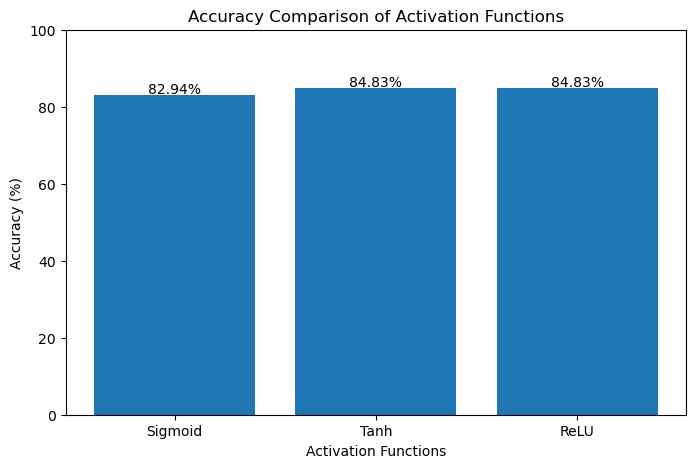

In [23]:
import numpy as np
import pandas as pd

#LOADING DATASET
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"
data = pd.read_csv(url, sep=';', header=None)

#LABELS
X = data.iloc[:, :-1].values.astype(float)  #stores columns except the final column
labels = data.iloc[:, -1].str.strip()

y = np.where(labels == 'RB', 1, 0) #stores the decision column
 
print("Class Distribution:")
print("RB:", np.sum(y == 1))
print("NRB:", np.sum(y == 0))

#SPLITTING THE DATA
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#SCALING/STANDARDIZATION
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

#EXTRA BIAS COLUMN
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

#SIGMOID FUNCTION
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#tanh FUNCTION
def tanh(z):
    return np.tanh(z)

#RELU FUNCTION
def relu(z):
    return np.maximum(0, z)

#COST FUNCTION
def compute_cost(X, y, h):

    m = len(y)

    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)

    return (-1 / m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )

#DEFINING ACTIVATION FUNCTIONS
activation_functions = {
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu
}

results = {}

for name, activation in activation_functions.items():

    print(f"\n==============================")
    print(f"{name} Activation Function")
    print(f"==============================")

    #INITIALIZING WEIGHTS
    theta = np.zeros(X_train.shape[1])

    #TRAINING THE MODEL
    learning_rate = 0.01
    iterations = 1000

    for i in range(iterations):

        z = X_train @ theta

        h = activation(z)

        h = np.clip(h, 1e-10, 1 - 1e-10)

        gradient = (1 / len(y_train)) * (X_train.T @ (h - y_train))

        theta -= learning_rate * gradient

        if i % 100 == 0:
            cost = compute_cost(X_train, y_train, h)
            print(f"Iteration {i}: Cost = {cost:.4f}")

    #PREDICTION
    probabilities = activation(X_test @ theta)

    predictions = (probabilities >= 0.5).astype(int)

    #ACCURACY
    accuracy = np.mean(predictions == y_test) * 100

    results[name] = accuracy

    print("\nTest Accuracy:", round(accuracy, 2), "%")

    #CONFUSION MATRIX
    cm = confusion_matrix(y_test, predictions)

    # LABELS
    labels = ["Non-Biodegradable", "Biodegradable"]

    # PLOT
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=labels)

    disp.plot(cmap="Purples")

    plt.title(f"{name} Confusion Matrix")
    plt.show()

    #classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

#FINAL COMPARISON
print("\n==============================")
print("FINAL COMPARISON")
print("==============================")

for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2f}%")

#plotting activation function accuracies
activation_names = list(results.keys())
activation_accuracies = list(results.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(activation_names, activation_accuracies)

plt.xlabel("Activation Functions")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Activation Functions")

#show values on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(0, 100)

plt.show()

Class Distribution:
RB: 356
NRB: 699

Sigmoid Activation Function
Iteration 0: Cost = 0.6931
Iteration 100: Cost = 0.3573
Iteration 200: Cost = 0.3236
Iteration 300: Cost = 0.3083
Iteration 400: Cost = 0.2993
Iteration 500: Cost = 0.2933
Iteration 600: Cost = 0.2890
Iteration 700: Cost = 0.2857
Iteration 800: Cost = 0.2831
Iteration 900: Cost = 0.2810
Iteration 1000: Cost = 0.2793
Iteration 1100: Cost = 0.2778
Iteration 1200: Cost = 0.2765
Iteration 1300: Cost = 0.2754
Iteration 1400: Cost = 0.2744
Iteration 1500: Cost = 0.2736
Iteration 1600: Cost = 0.2728
Iteration 1700: Cost = 0.2721
Iteration 1800: Cost = 0.2714
Iteration 1900: Cost = 0.2708
Iteration 2000: Cost = 0.2703
Iteration 2100: Cost = 0.2698
Iteration 2200: Cost = 0.2693
Iteration 2300: Cost = 0.2689
Iteration 2400: Cost = 0.2685
Iteration 2500: Cost = 0.2681
Iteration 2600: Cost = 0.2677
Iteration 2700: Cost = 0.2674
Iteration 2800: Cost = 0.2671
Iteration 2900: Cost = 0.2668
Iteration 3000: Cost = 0.2665
Iteration 3100: 

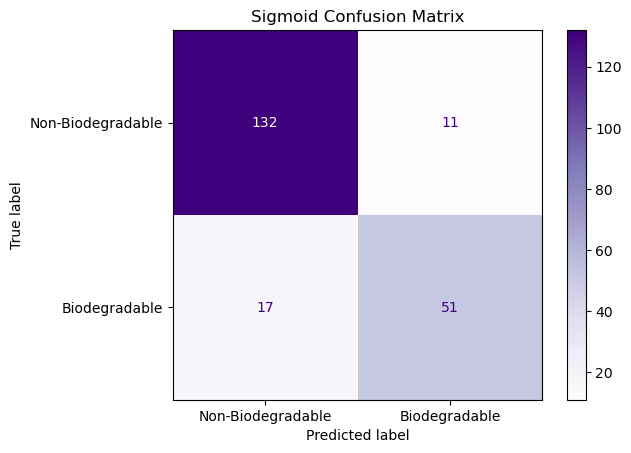


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       143
           1       0.82      0.75      0.78        68

    accuracy                           0.87       211
   macro avg       0.85      0.84      0.84       211
weighted avg       0.87      0.87      0.87       211


Tanh Activation Function
Iteration 0: Cost = 7.8572
Iteration 100: Cost = 0.4161
Iteration 200: Cost = 0.4459
Iteration 300: Cost = 0.4387
Iteration 400: Cost = 0.4349
Iteration 500: Cost = 0.4333
Iteration 600: Cost = 0.4343
Iteration 700: Cost = 0.4538
Iteration 800: Cost = 0.4745
Iteration 900: Cost = 0.4735
Iteration 1000: Cost = 0.4727
Iteration 1100: Cost = 0.4720
Iteration 1200: Cost = 0.4714
Iteration 1300: Cost = 0.4710
Iteration 1400: Cost = 0.4706
Iteration 1500: Cost = 0.4702
Iteration 1600: Cost = 0.4699
Iteration 1700: Cost = 0.4697
Iteration 1800: Cost = 0.4695
Iteration 1900: Cost = 0.4694
Iteration 2000: Cost = 0.4692
Iter

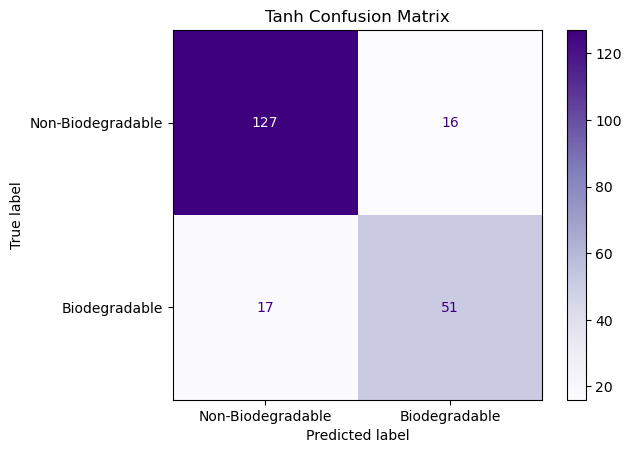


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       143
           1       0.76      0.75      0.76        68

    accuracy                           0.84       211
   macro avg       0.82      0.82      0.82       211
weighted avg       0.84      0.84      0.84       211


ReLU Activation Function
Iteration 0: Cost = 7.8572
Iteration 100: Cost = 0.4272
Iteration 200: Cost = 0.4392
Iteration 300: Cost = 0.4116
Iteration 400: Cost = 0.4065
Iteration 500: Cost = 0.3807
Iteration 600: Cost = 0.3769
Iteration 700: Cost = 0.3745
Iteration 800: Cost = 0.3728
Iteration 900: Cost = 0.3714
Iteration 1000: Cost = 0.3703
Iteration 1100: Cost = 0.3694
Iteration 1200: Cost = 0.3686
Iteration 1300: Cost = 0.3680
Iteration 1400: Cost = 0.3675
Iteration 1500: Cost = 0.3671
Iteration 1600: Cost = 0.3667
Iteration 1700: Cost = 0.3664
Iteration 1800: Cost = 0.3661
Iteration 1900: Cost = 0.3659
Iteration 2000: Cost = 0.3656
Iter

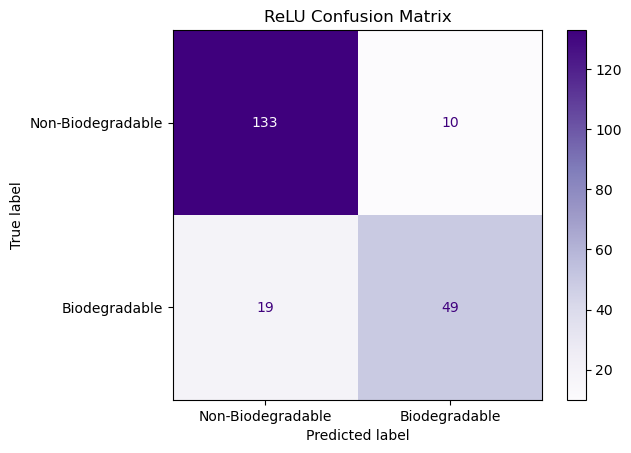


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       143
           1       0.83      0.72      0.77        68

    accuracy                           0.86       211
   macro avg       0.85      0.83      0.84       211
weighted avg       0.86      0.86      0.86       211


FINAL COMPARISON
Sigmoid: 86.73%
Tanh: 84.36%
ReLU: 86.26%


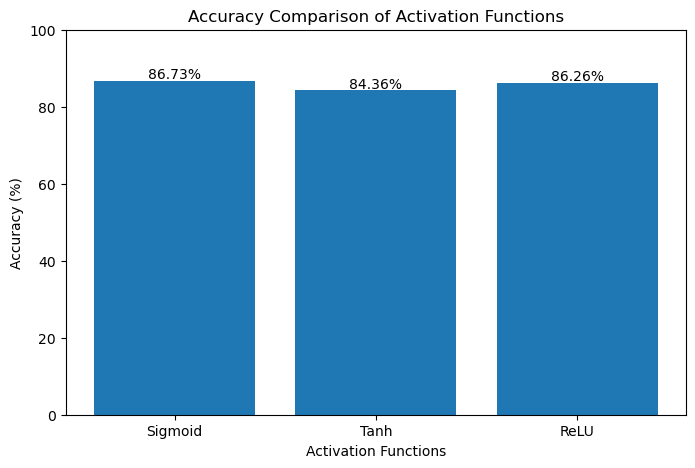

In [15]:
import numpy as np
import pandas as pd

#loading data set
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"
data = pd.read_csv(url, sep=';', header=None)

#labels
X = data.iloc[:, :-1].values.astype(float)  #stores columns except the final column
labels = data.iloc[:, -1].str.strip()

y = np.where(labels == 'RB', 1, 0) #stores the decision column
 
print("Class Distribution:")
print("RB:", np.sum(y == 1))
print("NRB:", np.sum(y == 0))

#splitting the data
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#standardization/scaling
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

#extra bias column
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#tanh function
def tanh(z):
    return np.tanh(z)

#relu function
def relu(z):
    return np.maximum(0, z)

#cost function
def compute_cost(X, y, h):

    m = len(y)

    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)

    return (-1 / m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )

#activation functions
activation_functions = {
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu
}

results = {}

for name, activation in activation_functions.items():

    print(f"\n==============================")
    print(f"{name} Activation Function")
    print(f"==============================")

    #initializing weights
    theta = np.zeros(X_train.shape[1])

    #training the model
    learning_rate = 0.1
    iterations = 5000

    for i in range(iterations):

        z = X_train @ theta

        h = activation(z)

        h = np.clip(h, 1e-10, 1 - 1e-10)

        gradient = (1 / len(y_train)) * (X_train.T @ (h - y_train))

        theta -= learning_rate * gradient

        if i % 100 == 0:
            cost = compute_cost(X_train, y_train, h)
            print(f"Iteration {i}: Cost = {cost:.4f}")

    #prediction
    probabilities = activation(X_test @ theta)

    predictions = (probabilities >= 0.5).astype(int)

    #accuracy
    accuracy = np.mean(predictions == y_test) * 100

    results[name] = accuracy

    print("\nTest Accuracy:", round(accuracy, 2), "%")

    #confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Labels
    labels = ["Non-Biodegradable", "Biodegradable"]

    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=labels)

    disp.plot(cmap="Purples")

    plt.title(f"{name} Confusion Matrix")
    plt.show()

    #classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

#final comparison
print("\n==============================")
print("FINAL COMPARISON")
print("==============================")

for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2f}%")

#plotting activation function accuracies
activation_names = list(results.keys())
activation_accuracies = list(results.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(activation_names, activation_accuracies)

plt.xlabel("Activation Functions")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Activation Functions")

#show values on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(0, 100)

plt.show()


SKLEARN LOGISTIC REGRESSION

Sklearn Accuracy: 87.68%


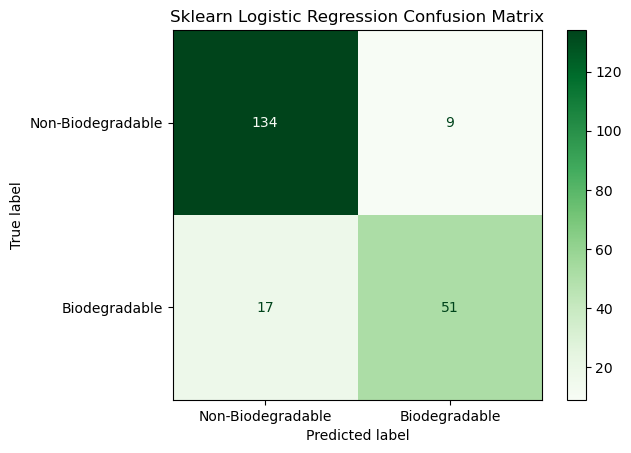


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       143
           1       0.85      0.75      0.80        68

    accuracy                           0.88       211
   macro avg       0.87      0.84      0.85       211
weighted avg       0.88      0.88      0.87       211



In [22]:
#sklearn logistic regression comparison
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("\n==============================")
print("SKLEARN LOGISTIC REGRESSION")
print("==============================")

#creating sklearn model
sklearn_model = LogisticRegression(max_iter=1000)

#training model
sklearn_model.fit(X_train[:, 1:], y_train)

#prediction
sklearn_predictions = sklearn_model.predict(X_test[:, 1:])

#accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions) * 100

print(f"\nSklearn Accuracy: {sklearn_accuracy:.2f}%")

#confusion matrix
cm = confusion_matrix(y_test, sklearn_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Biodegradable", "Biodegradable"]
)

disp.plot(cmap="Greens")

plt.title("Sklearn Logistic Regression Confusion Matrix")
plt.show()

#classification report
print("\nClassification Report:\n")
print(classification_report(y_test, sklearn_predictions))


In [17]:
#final comparison
print("\n==============================")
print("CUSTOM VS SKLEARN")
print("==============================")

print(f"Custom Sigmoid Model : {results['Sigmoid']:.2f}%")
print(f"Sklearn Logistic Regression : {sklearn_accuracy:.2f}%")


CUSTOM VS SKLEARN
Custom Sigmoid Model : 86.73%
Sklearn Logistic Regression : 87.68%


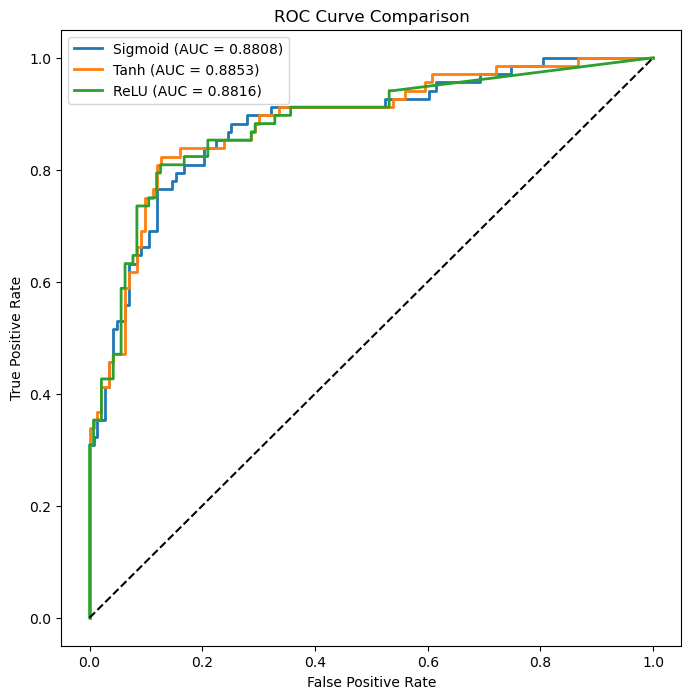

In [37]:
#ROC curve comparison
plt.figure(figsize=(8,8))

for name, activation in activation_functions.items():

    theta = trained_weights[name]

    probabilities = activation(X_test @ theta)

    #tanh normalization
    if name == "Tanh":
        probabilities = (probabilities + 1) / 2

    #relu normalization
    if name == "ReLU":

        probabilities = probabilities / (
            np.max(probabilities) + 1e-10
        )

    #roc calculations
    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    roc_auc = auc(fpr, tpr)

    #plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

#random classifier reference
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [27]:
#references
#https://heena-sharma.medium.com/logistic-regression-python-implementation-from-scratch-without-using-sklearn-d3fca7d3dae7